# compare refined ensemble vs full ensemble MEIs

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pickle
import torch
import sys
from typing import Callable

repo_path = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/"
sys.path.append(repo_path)

import thesis.code.validate_online_meis.utils as ut
import thesis.code.validate_online_analysis.utils as val_ut

In [3]:
from thesis.code.plot import plot as plotter

plotter.set_default_params(kind='paper')

In [4]:
DATA_DIR ="/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/validate_online_meis"
FIG_DIR = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/figures/validate_online_meis"
os.makedirs(FIG_DIR,exist_ok=True)

# load data

In [5]:
# enseble model mei container, single member, and srf and trf 
ensemble_conatiner_path = "GCL0_20251003_212914_refined_ensemble/mei_data_container.pkl"
session_dict_raw_path = "GCL0_20251003_212914_refined_ensemble/session_dict_raw.pkl"

ensemble_container = ut.load_torch_file(os.path.join(DATA_DIR,ensemble_conatiner_path))
session_dict_raw = ut.load_file_from_pickle(os.path.join(DATA_DIR,session_dict_raw_path))


Note: The session dict of the refined ensemble has session name online_session_1_ventral1_20251001, because I trained it then, but the data corresponds to a different session name in the session dicts loaded from openretina.

In [6]:
ONLINE_SESSION_ID = list(session_dict_raw.keys())[0]
print(f"Online session id: {ONLINE_SESSION_ID}")

Online session id: online_session_1_ventral1_20251001


In [7]:
from model_in_the_loop.utils.model_training import (get_predictions_targets_one_dataloader,
                                                    load_pretrained_ensemble_model,
                                                    train_or_refine_member_or_ensemble,
                                                    get_dataloaders_and_data_info,
                                                    load_stimuli,
                                                    )

from model_in_the_loop.utils.stimulus_optimization import (reconstruct_mei_from_decomposed,
                                                           center_member_or_ensemble_readouts,
                                                           generate_opt_stim_for_neuron_list,
                                                            decompose_mei, get_model_mei_response
                                                           )


from openretina.data_io.hoefling_2024.responses import make_final_responses,filter_responses

from thesis.code.online_quality_and_celltype.utils import find_roi_partner_highest_correl

## compute missing data (or load after)

### mei_container full ensemble

In [8]:
# load fully trained ensemble 
full_ensemble = load_pretrained_ensemble_model(os.path.join(
    repo_path,
    "model_in_the_loop/models/full_ensemble"),
    seeds = ["000","1000","2000","3000","4000"],)


Loading model from /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/model_in_the_loop/models/full_ensemble/seed_000.ckpt


Loading model from /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/model_in_the_loop/models/full_ensemble/seed_1000.ckpt
Loading model from /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/model_in_the_loop/models/full_ensemble/seed_2000.ckpt
Loading model from /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/model_in_the_loop/models/full_ensemble/seed_3000.ckpt
Loading model from /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/model_in_the_loop/models/full_ensemble/seed_4000.ckpt


In [9]:
# load configs
from model_in_the_loop.utils.hydra_utils import load_config
cfg = load_config()

In [10]:
OFFLINE_SESSION_ID = "session_1_ventral1_20200226"

In [11]:
offline_session_kwargs = full_ensemble.members[0].data_info["sessions_kwargs"][OFFLINE_SESSION_ID]
offline_roi_ids = offline_session_kwargs["roi_ids"] 

In [12]:
# movies_dict = load_stimuli(
#     cfg.model_configs
# )
# neuron_data_dict = make_final_responses(session_dict_raw)

# # load dataloader
# dataloaders,data_info = get_dataloaders_and_data_info(
#     cfg.model_configs,
#     neuron_data_dict,
#     movies_dict
# )

In [13]:
# # save 
#
full_container_path = os.path.join(DATA_DIR,"figure_data",f"mei_data_container_full_ensemble_{OFFLINE_SESSION_ID}.pkl")
# with open(full_container_path,"wb") as f:
#     pickle.dump(mei_data_container,f)

# load
with open(full_container_path,"rb") as f:
    full_ensemble_mei_data_container = pickle.load(f)


## predictions on testset full ensemble

In [14]:
# pred_full_ensemble, target_dataloader = get_predictions_targets_one_dataloader(
#     model = full_ensemble,
#     session_id= OFFLINE_SESSION_ID, # this is to access the readout from the offline session name
#     session_dataloader=  dataloaders["test"][ONLINE_SESSION_ID],
# )
# print(f"Predictions shape: {pred_full_ensemble.shape}, Target shape: {target_dataloader.shape}")

In [15]:
full_ensemble_predictions_path = os.path.join(DATA_DIR,"figure_data",f"full_ensemble_predictions_offline_{OFFLINE_SESSION_ID}_online_{ONLINE_SESSION_ID}.pkl")

# with open(full_ensemble_predictions_path,"wb") as f:
#     # dump
#     pickle.dump(pred_full_ensemble,f)

with open(full_ensemble_predictions_path,"rb") as f:
    pred_full_ensemble = pickle.load(f)


## MEI data container refined ensemble 

In [16]:
# cfg.model_configs.paths.load_model_path = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/model_in_the_loop/models/missing_first_ensemble"
# pre_time = perf_counter()
# refined_ensemble, best_model_path = train_or_refine_member_or_ensemble(
#     model_configs=cfg.model_configs,
#     dataloaders=dataloaders,
#     data_info=data_info,
# )
# post_time = perf_counter()
# print(f"Refinement time: {post_time - pre_time} seconds.")

In [17]:
# # mei container refining ensemble 
# refined_ensemble_mei_data_container = get_mei_container(
#     model=refined_ensemble,
#     session_id=ONLINE_SESSION_ID,
#     cfg=cfg,
# )

In [18]:
# # save refined 
refined_container_path = os.path.join(DATA_DIR,"figure_data",f"mei_data_container_refined_ensemble_{ONLINE_SESSION_ID}.pkl")
# with open(refined_container_path,"wb") as f:
#     pickle.dump(refined_ensemble_mei_data_container,f)

# load refined 
with open(refined_container_path,"rb") as f:
    refined_ensemble_mei_data_container = pickle.load(f)

In [19]:
# # get predictions for refined ensemble 
# pred_refined_ensemble, target_dataloader = get_predictions_targets_one_dataloader(
#     model = refined_ensemble,
#     session_id= ONLINE_SESSION_ID, # here we want to access the online session readout
#     session_dataloader=  dataloaders["test"][ONLINE_SESSION_ID],
# )

In [20]:
# save
refined_ensemble_predictions_path = os.path.join(DATA_DIR,"figure_data",f"refined_ensemble_predictions_online_{ONLINE_SESSION_ID}.pkl")
# with open(refined_ensemble_predictions_path,"wb") as f:
#     # dump
#     pickle.dump(pred_refined_ensemble,f)

# load 
with open(refined_ensemble_predictions_path,"rb") as f:
    pred_refined_ensemble = pickle.load(f)

## ROI mapping

In [21]:
# we need to load the raw session dict and neuron data dict from the offline sessions
val_online_analysis_dir = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/validate_online_analysis"
offline_spikes = ut.load_file_from_pickle(os.path.join(val_online_analysis_dir,"offline_spikes_20200226.pkl"))

In [22]:
session_dict_raw[ONLINE_SESSION_ID].keys()

dict_keys(['animal_gender', 'date', 'scan_sequence_idx', 'experimenter', 'eye', 'exp_num', 'field', 'cond1', 'roi_mask', 'roi_ids', 'group_assignment', 'group_confidences', 'chirp_qi', 'ds_index', 'pref_dir', 'os_index', 'd_qi', 'roi_size_um2', 'natural_preprocessed_traces', 'natural_smoothed_traces', 'natural_preprocessed_traces_times_t0', 'natural_preprocessed_traces_times_dt', 'natural_raw_traces', 'natural_traces_times_t0', 'natural_traces_times_dt', 'natural_trigger_times', 'natural_spikes', 'natural_traces_times', 'natural_preprocessed_traces_times'])

In [23]:
online_spikes = session_dict_raw[ONLINE_SESSION_ID]["natural_spikes"]
online_spikes_nonnan = np.stack([train[~np.isnan(train)] for train in online_spikes])
offline_spikes_nonnan = np.stack([train[~np.isnan(train)] for train in offline_spikes["spikes"]])
offline_trace_idx,correls = find_roi_partner_highest_correl(online_spikes_nonnan,offline_spikes_nonnan)

In [26]:
# print numbers for reportin
print(f"{offline_spikes_nonnan.shape=}")

offline_spikes_nonnan.shape=(86, 4972)


In [36]:
offline_trace_idx2offline_roi_id = {idx:offline_spikes["roi_ids"][idx] for idx in offline_trace_idx}
offline_roi_id2offline_readout_idx = {roi_id:readout_idx for readout_idx,roi_id in enumerate(offline_session_kwargs["roi_ids"])}

def get_offline_readout_idx_from_online_readout_idx(offline_trace_idx_array,offline_trace_idx2offline_roi_id,offline_roi_id2offline_readout_idx):
    online_readout_idx2offline_readout_idx = {}

    for online_readout_idx,offline_trace_idx in enumerate(offline_trace_idx_array):
        
        offline_roi_id = offline_trace_idx2offline_roi_id[offline_trace_idx]
        if offline_roi_id not in offline_roi_id2offline_readout_idx:
            print(f"Offline roi id {offline_roi_id} not found in offline roi id to readout idx mapping. Skipping.")
            continue
        offline_readout_idx = offline_roi_id2offline_readout_idx[offline_roi_id]
        online_readout_idx2offline_readout_idx[online_readout_idx] = offline_readout_idx
    return online_readout_idx2offline_readout_idx

online_readout_idx2offline_readout_idx = get_offline_readout_idx_from_online_readout_idx(
                                                            np.array(offline_trace_idx),
                                                            offline_trace_idx2offline_roi_id,
                                                            offline_roi_id2offline_readout_idx
                                                            )


Offline roi id 61 not found in offline roi id to readout idx mapping. Skipping.


(<Figure size 600x600 with 10 Axes>, <Axes: xlabel='Time [s]'>)

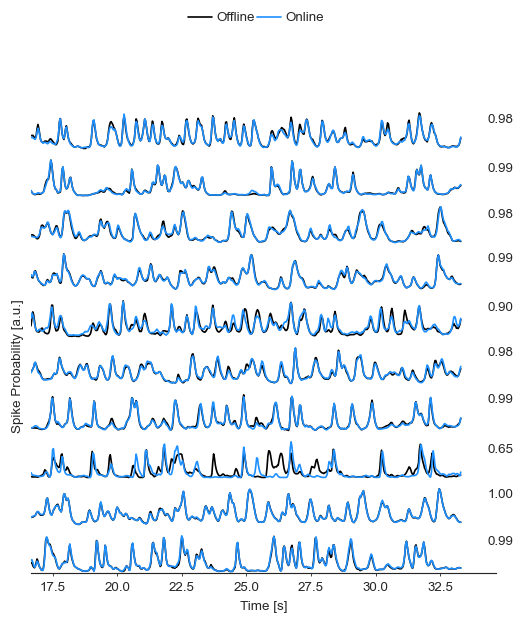

In [37]:
val_ut.plot_online_offline(
    offline_signals=offline_spikes_nonnan[offline_trace_idx[:10]],
    online_signals=online_spikes_nonnan[:10],
    time_window=(500,1000)
)

In [59]:
def plot_prediction_similarity(online_readout_indices,
                               online_readout_idx2offline_readout_idx,
                               online_predictions,
                               offline_predictions,
                               time_window= (0,720),
                               axes =None):

    # fetch data
    corresponding_offline_readout_indices = [online_readout_idx2offline_readout_idx[idx] for idx in online_readout_indices]

    sub_online_predictions = online_predictions[:,online_readout_indices]
    sub_offline_predictions = offline_predictions[:,corresponding_offline_readout_indices]
    print(f"Sub online predictions shape: {sub_online_predictions.shape}, Sub offline predictions shape: {sub_offline_predictions.shape}")
    # put in plot_online_offline
    val_ut.plot_online_offline(
        offline_signals=sub_offline_predictions.T,
        online_signals=sub_online_predictions.T,
        time_window=time_window,
        axes = axes,
        global_y_label = "Predicted spike probability [a.u.]"
    )
def print_correlation(online_readout_indices,
                      online_readout_idx2offline_readout_idx,
                      online_predictions,
                      offline_predictions):
    corresponding_offline_readout_indices = [online_readout_idx2offline_readout_idx[idx] for idx in online_readout_indices]

    sub_online_predictions = online_predictions[:,online_readout_indices]
    sub_offline_predictions = offline_predictions[:,corresponding_offline_readout_indices]

    all_correlts = []
    for online_array,offline_array in zip(sub_online_predictions.T,sub_offline_predictions.T):
        correlt = np.corrcoef(online_array,offline_array)[0,1]
        all_correlts.append(correlt)
    print(f"Mean correlation: {np.mean(all_correlts):.2f} standard deviation: {np.std(all_correlts):.3f}")


# Plot comparison of predictions

Sub online predictions shape: (720, 8), Sub offline predictions shape: (720, 8)


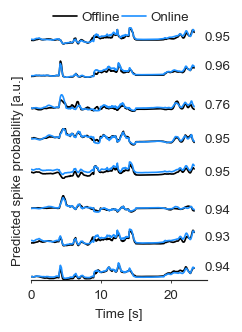

In [39]:
plotfirstn = 8
fig,axes = plt.subplots(plotfirstn,1,figsize =plotter.figsize_from_frac(1/4,1/3))
plot_prediction_similarity(
    online_readout_indices=list(online_readout_idx2offline_readout_idx.keys())[:plotfirstn],
    online_readout_idx2offline_readout_idx=online_readout_idx2offline_readout_idx,
    online_predictions=pred_refined_ensemble,
    offline_predictions=pred_full_ensemble,
    time_window=(0,700),
    axes =axes
)
plotter.tight_layout()

save_path = os.path.join(FIG_DIR,"prediction_similarity_offline_vs_online_20200226.svg")
fig.savefig(save_path,format="svg",bbox_inches='tight')

In [60]:
# print correlations 
print_correlation(
    online_readout_indices=list(online_readout_idx2offline_readout_idx.keys()),
    online_readout_idx2offline_readout_idx=online_readout_idx2offline_readout_idx,
    online_predictions=pred_refined_ensemble,
    offline_predictions=pred_full_ensemble,
)

Mean correlation: 0.90 standard deviation: 0.092


# plot comparison of meis

In [40]:
full_ensemble_mei_data_container.head()

,readout_idx,roi_id,mei_id,seed,mei,temporal_kernels,spatial_kernels,stability
0,0,1,roi_1_seed_111,111,"[[[tensor([-3.3487e-06, 2.4540e-06, 5.9563e-...","[[-0.00041455802, -0.0007937895, -0.0011074399...","[[[0.0065062684, -0.004767855, -0.0115725435, ...",stable
1,1,2,roi_2_seed_111,111,"[[[tensor([ 1.6201e-05, 1.4245e-05, 1.1283e-...","[[-0.000942539, -0.0018175495, -0.0025689797, ...","[[[-0.013447706, -0.011824202, -0.009365245, -...",stable
2,2,5,roi_5_seed_111,111,"[[[tensor([-3.6558e-04, -5.7206e-04, -5.7847e-...","[[-0.0056012385, -0.010719443, -0.014959476, -...","[[[0.05297002, 0.08288696, 0.08381675, 0.03295...",stable
3,3,7,roi_7_seed_111,111,"[[[tensor([-2.3238e-05, -1.3026e-05, 8.1400e-...","[[0.0012136586, 0.0022939632, 0.0031549265, 0....","[[[-0.012414648, -0.0069586975, 0.004348618, 0...",stable
4,4,9,roi_9_seed_111,111,"[[[tensor([-7.9784e-05, -2.3335e-04, -4.0910e-...","[[-0.0038032448, -0.007468449, -0.010848428, -...","[[[0.019052355, 0.055724174, 0.097691216, 0.12...",stable


In [76]:

def fetch_channel_kernels(online_readout_indices,
                          online_readout_idx2offline_readout_idx,
                          online_mei_container,
                          offline_mei_container,
                          kernel_type = "temporal",
                          channels = "uv"):
    online_meis_subset = online_mei_container[online_mei_container["readout_idx"].isin(online_readout_indices)].copy()
    online_meis_subset["offline_readout_idx"] = online_meis_subset["readout_idx"].map(online_readout_idx2offline_readout_idx)
    offline_meis_subset = offline_mei_container[offline_mei_container["readout_idx"].isin(online_meis_subset["offline_readout_idx"].to_list())].copy()
    combined_df = online_meis_subset.merge(offline_meis_subset,left_on="offline_readout_idx",right_on="readout_idx",suffixes=("_online","_offline"))
    if channels == "uv":
        channel_idx = 1
    elif channels == "green":
        channel_idx = 0
    else:
        raise ValueError(f"Unknown channels {channels}. Choose from 'uv' or 'green'.")
    
    online_channel_kernels = np.stack(combined_df[f"{kernel_type}_kernels_online"].apply(lambda x: x[channel_idx]).to_list())
    offline_channel_kernels = np.stack( combined_df[f"{kernel_type}_kernels_offline"].apply(lambda x: x[channel_idx]).to_list())
    return online_channel_kernels,offline_channel_kernels



def plot_temporal_kernels_comparison(online_readout_indices,
                        online_readout_idx2offline_readout_idx,
                        online_mei_container,
                        offline_mei_container,
                        channels = "uv",
                        axes=None,
         ):


    online_channel_kernels,offline_channel_kernels = fetch_channel_kernels(
        online_readout_indices=online_readout_indices,
        online_readout_idx2offline_readout_idx=online_readout_idx2offline_readout_idx,
        online_mei_container=online_mei_container,
        offline_mei_container=offline_mei_container,
        kernel_type = "temporal",
        channels = channels,
    )



    if axes is None:
        fig,axes = plt.subplots(len(online_readout_indices),1,figsize=plotter.figsize_from_frac(1/3,1/2 ))
    

    # plot
    val_ut.plot_online_offline(
        offline_signals=offline_channel_kernels,
        online_signals=online_channel_kernels,
        axes = axes,
        global_y_label = "Standardized pixel intensity [sd]",
    )

def print_kernel_correlation (online_readout_indices,
                        online_readout_idx2offline_readout_idx,
                        online_mei_container,
                        offline_mei_container,
                        channels: list[str] | str = "uv",
                        np_func: Callable= np.mean) -> None:
    
    if isinstance(channels,str):
        channels = [channels]
    else:
        assert isinstance(channels,list), "channels must be a string or list of strings."
        assert all(isinstance(ch, str) for ch in channels), "All elements in channels list must be strings."
    
    for single_channel in channels:
        online_channel_kernels,offline_channel_kernels = fetch_channel_kernels(
            online_readout_indices=online_readout_indices,
            online_readout_idx2offline_readout_idx=online_readout_idx2offline_readout_idx,
            online_mei_container=online_mei_container,
            offline_mei_container=offline_mei_container,
            kernel_type = "temporal",
            channels = single_channel,
        )
        all_correls = []
        for online_kernel,offline_kernel in zip(online_channel_kernels,offline_channel_kernels):
            correlt = np.corrcoef(online_kernel,offline_kernel)[0,1]
            all_correls.append(correlt)
        print(f"Temporal kernel correlation channels {single_channel} - Func name {np_func.__name__}: {np_func(all_correls):.2f}, Std: {np.std(all_correls):.3f}")


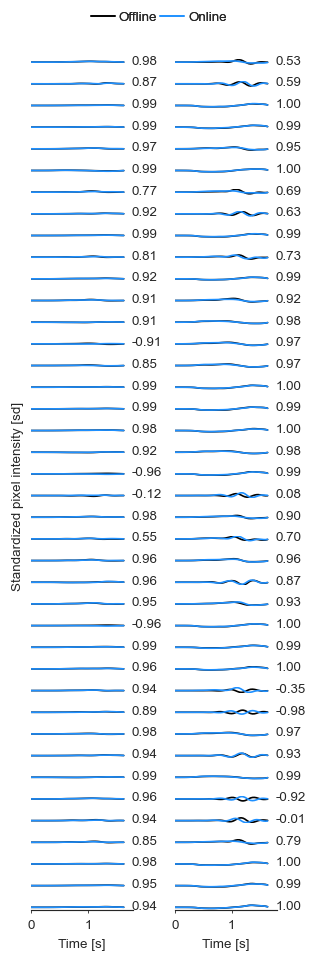

In [81]:
plotfirstn = 40
fig,axes = plt.subplots(plotfirstn,2,figsize=plotter.figsize_from_frac(1/3,1),sharey=True)
plot_temporal_kernels_comparison(
    online_readout_indices=list(online_readout_idx2offline_readout_idx.keys())[:plotfirstn],
    online_readout_idx2offline_readout_idx=online_readout_idx2offline_readout_idx,
    online_mei_container=refined_ensemble_mei_data_container,
    offline_mei_container=full_ensemble_mei_data_container,
    axes = axes[:,1],
    channels = "uv",
)

# remove y_label
axes[plotfirstn//2,1].set_ylabel("")

plot_temporal_kernels_comparison(
    online_readout_indices=list(online_readout_idx2offline_readout_idx.keys())[:plotfirstn],
    online_readout_idx2offline_readout_idx=online_readout_idx2offline_readout_idx,
    online_mei_container=refined_ensemble_mei_data_container,
    offline_mei_container=full_ensemble_mei_data_container,
    axes = axes[:,0],
    channels = "green",
)



plotter.tight_layout()

save_path = os.path.join(FIG_DIR,"temporal_kernels_offline_vs_online_20200226_uv_green.svg")
# fig.savefig(save_path,format="svg",bbox_inches='tight')


In [85]:

# print correlst mean - NOTE: there are some kernels that correlate strongly negatively 
print_kernel_correlation(
    online_readout_indices=list(online_readout_idx2offline_readout_idx.keys()),
    online_readout_idx2offline_readout_idx=online_readout_idx2offline_readout_idx,
    online_mei_container=refined_ensemble_mei_data_container,
    offline_mei_container=full_ensemble_mei_data_container, 
    channels = ["green","uv"],
    np_func= np.mean 

)

# median is robust against this
print_kernel_correlation(
    online_readout_indices=list(online_readout_idx2offline_readout_idx.keys()),
    online_readout_idx2offline_readout_idx=online_readout_idx2offline_readout_idx,
    online_mei_container=refined_ensemble_mei_data_container,
    offline_mei_container=full_ensemble_mei_data_container, 
    channels = ["green","uv"],
    np_func= np.median 

)

Temporal kernel correlation channels green - Func name mean: 0.73, Std: 0.579
Temporal kernel correlation channels uv - Func name mean: 0.78, Std: 0.450
Temporal kernel correlation channels green - Func name median: 0.95, Std: 0.579
Temporal kernel correlation channels uv - Func name median: 0.98, Std: 0.450


In [84]:
def plot_spatial_kernel_comparison(online_readout_indices,
                        online_readout_idx2offline_readout_idx,
                        online_mei_container,
                        offline_mei_container,
                        channel: str,
                        plot_func_kwargs={},
                        axes=None):


    online_channel_kernels,offline_channel_kernels = fetch_channel_kernels(
        online_readout_indices=online_readout_indices,
        online_readout_idx2offline_readout_idx=online_readout_idx2offline_readout_idx,
        online_mei_container=online_mei_container,
        offline_mei_container=offline_mei_container,
        kernel_type = "spatial",
        channels = channel,
    )

    if axes is None:
        fig,axes = plt.subplots(len(online_readout_indices),1,figsize=plotter.figsize_from_frac(1/4,1/2 ))
    

    # plot
    val_ut.plot_online_offline_2d(
        offline_2d=offline_channel_kernels,
        online_2d=online_channel_kernels,
            **plot_func_kwargs,
        axes = axes,
        cmap = "RdBu_r"
    )

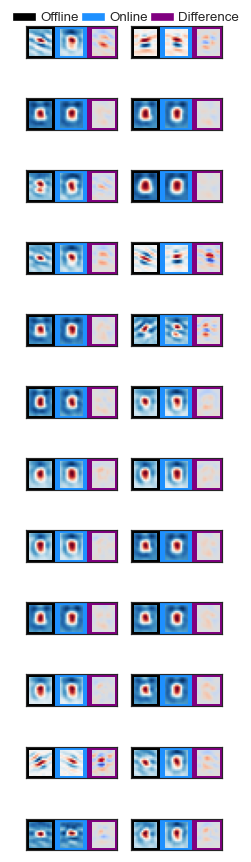

In [86]:
plotfirstn = 8 *3
fig,axes = plt.subplots(int(plotfirstn/2),2,figsize=plotter.figsize_from_frac(1/4,1),sharey=True)
channels = "uv"
plot_spatial_kernel_comparison(
    online_readout_indices=list(online_readout_idx2offline_readout_idx.keys())[:plotfirstn],
    online_readout_idx2offline_readout_idx=online_readout_idx2offline_readout_idx,
    online_mei_container=refined_ensemble_mei_data_container,
    offline_mei_container=full_ensemble_mei_data_container,
    axes = axes,
    plot_func_kwargs={
        "add_comparison_array": True,
        "ncol": 2,
    },
    channel = channels,
)

#add legendt 
axes = ut.add_online_offline_comparison_legend(axes)

# plotter.tight_layout(h_pad = 1)  

save_path = os.path.join(FIG_DIR,"spatial_kernels_offline_vs_online_20200226_uv.svg")
# fig.savefig(save_path,format="svg",bbox_inches='tight')





Index(['readout_idx_online', 'roi_id_online', 'mei_id_online', 'seed_online',
       'mei_online', 'temporal_kernels_online', 'spatial_kernels_online',
       'stability_online', 'offline_readout_idx', 'readout_idx_offline',
       'roi_id_offline', 'mei_id_offline', 'seed_offline', 'mei_offline',
       'temporal_kernels_offline', 'spatial_kernels_offline',
       'stability_offline'],
      dtype='object')


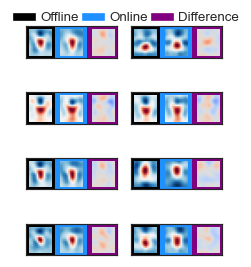

In [ ]:
plotfirstn = 8
fig,axes = plt.subplots(int(plotfirstn/2),2,figsize=plotter.figsize_from_frac(1/4,1/3),sharey=True)
channels = "green"
plot_spatial_kernel_comparison(
    online_readout_indices=list(online_readout_idx2offline_readout_idx.keys())[:plotfirstn],
    online_readout_idx2offline_readout_idx=online_readout_idx2offline_readout_idx,
    online_mei_container=refined_ensemble_mei_data_container,
    offline_mei_container=full_ensemble_mei_data_container,
    axes = axes,
    plot_func_kwargs={
        "add_comparison_array": True,
        "ncol": 2,
    },
    channels = channels,
)
# plotter.tight_layout()  

# add legend
axes = ut.add_online_offline_comparison_legend(axes)

save_path = os.path.join(FIG_DIR,f"spatial_kernels_{channels}_offline_vs_online_20200226_.svg")
fig.savefig(save_path,format="svg",bbox_inches='tight')



In [46]:
offline_time = 225 *5
online_time = 107

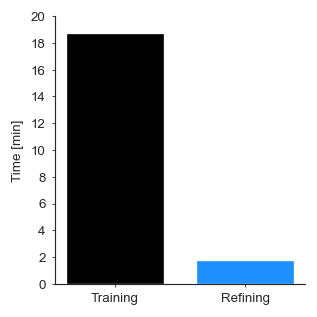

In [47]:
fig,ax = plt.subplots(figsize=plotter.figsize_from_frac(1/3,1/3))
val_ut.plot_online_offline_bar(
    offline_val = [offline_time / 60],
    online_val= [online_time / 60],
    axes = ax,
    ylabel = "Time [min]",
    labels = ["Training", "Refining",]
)
plotter.tight_layout()

# save it 
save_path = os.path.join(FIG_DIR,"training_refining_time_comparison.svg")
fig.savefig(save_path,format="svg")